In [1]:
import sqlite3
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

DB = '../data/humans_clean.sqlite3'
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

# ---- POLITIES: short-lived (10yr bins) ----
short_lived = [
    # --- original 17 ---
    ('USSR',               'Union of Soviet Socialist Republics',          1991),
    ('East Germany',       'German Democratic Republic',                   1990),
    ('Austria-Hungary',    'Austria-Hungary',                              1918),
    ('German Empire',      'German Empire',                                1919),
    ('Yugoslavia',         'Socialist Federal Republic of Yugoslavia',     1991),
    ('Francoist Spain',    'Francoist Spain',                              1975),
    ('Russian Empire',     'Russian Empire',                               1916),
    ('Empire of Japan',    '(Empire of Japan);Empire of Japan',            1945),
    ('Czechoslovakia',     'Czechoslovakia',                               1991),
    ('Romania (Soc.)',     'Socialist Republic of Romania',                1989),
    ("Hungary (People's)", "Hungarian People's Republic",                  1989),
    ("Bulgaria (People's)","People's Republic of Bulgaria",               1990),
    ('Pahlavi Dynasty',    'Pahlavi Dynasty',                              1978),
    ('Austrian Empire',    'Austrian Empire',                              1867),
    ('Kingdom of Romania', 'Kingdom of Romania',                           1947),
    ('Estado Novo',        'Estado Novo',                                  1975),
    ('Kingdom of France',  '(Kingdom of France);Kingdom of France',       1791),
    # --- new: major 20th-c collapses ---
    ('Nazi Germany',       'Nazi Germany',                                 1944),
    ('Weimar Republic',    'Weimar Republic',                              1935),
    ('2nd Polish Republic','Second Polish Republic',                       1939),
    ('Sweden-Norway',      'United Kingdoms of Sweden and Norway',         1904),
    ('Republic of Austria','Republic of Austria',                          1937),
    ('2nd Spanish Republic','Second Spanish Republic',                     1938),
    ('1st French Empire',  '(First French Empire);First French Empire',    1814),
    ('Bourbon France',     '(First French Empire);Bourbon Kingdom of France', 1847),
    ('Vichy France',       'Vichy France',                                 1943),
    ('Kingdom of Greece',  'Kingdom of Greece',                            1966),
    ('Empire of Brazil',   'Empire of Brazil',                             1889),
    ('Kingdom of Lithuania','Kingdom of Lithuania',                         1939),
    ("Mongolian People's", "Mongolian People's Republic",                  1991),
    ('Kingdom of Iraq',    'Kingdom of Iraq',                              1957),
    ('Kingdom of Afghanistan','Kingdom of Afghanistan',                    1972),
    ('Croatia (WWII)',     'Independent State of Croatia',                 1944),
    ('Rattanakosin',       'Rattanakosin Kingdom',                         1931),
    # --- new: German/Italian unification victims ---
    ('Kingdom of Bavaria', 'Kingdom of Bavaria',                           1870),
    ('Kingdom of Sardinia','Kingdom of Sardinia',                          1861),
    ('Two Sicilies',       'Kingdom of the Two Sicilies',                  1860),
    ('K. of Württemberg',  'Kingdom of Württemberg',                       1870),
    ('Kingdom of Hanover', 'Kingdom of Hanover',                           1865),
    ('Electorate of Hesse','Electorate of Hesse',                          1867),
    ('GD of Hesse',        'Grand Duchy of Hesse',                         1870),
    ('GD of Baden',        'Grand Duchy of Baden',                         1870),
    ('Free City Hamburg',  'Free City of Hamburg',                          1870),
    ('Free City Krakow',   'Free City of Krakow',                          1845),
    # --- new: other ---
    ('Qajar Dynasty',      'Qajar Dynasty',                                1923),
    ('Moldavia-Wallachia', 'United Principalities of Moldavia and Wallachia', 1916),
    ('Helvetic Republic',  'Helvetic Republic',                            1814),
    ('Electorate Hanover', 'Electorate of Hanover',                        1802),
    ('Tsardom of Russia',  'Tsardom of Russia',                            1720),
]

# ---- POLITIES: long-lived (25yr bins) ----
long_lived = [
    # --- original 14 ---
    ('Ming Dynasty',        'Ming Dynasty',                                1644),
    ('Southern Song',       'Southern Song',                               1278),
    ('Rep. of Venice',      'Republic of Venice',                          1796),
    ('Polish-Lithuanian',   'Polish-Lithuanian Commonwealth',              1793),
    ('Swedish Empire',      'Swedish Empire',                              1814),
    ('Rep. of Florence',    'Republic of Florence',                        1737),
    ('Mongol Empire',       'Mongol Empire',                               1293),
    ('Ottoman Empire',      'Ottoman Empire;(Ottoman Empire)',             1922),
    ('Qing Dynasty',        '(Qing Dynasty);Qing Dynasty',                1911),
    ('Dutch Republic',      '(Dutch Republic);Dutch Republic',             1795),
    ('Kingdom of Portugal', 'Kingdom of Portugal',                         1911),
    ('Tokugawa Shogunate',  'Tokugawa Shogunate;(Tokugawa Shogunate)',    1868),
    ('Papal States',        'Papal States',                                1870),
    ('Joseon',              'Joseon',                                      1897),
    # --- new: ancient/medieval ---
    ('Tang Dynasty',        'Tang Dynasty;(Tang Dynasty)',                  910),
    ('Han Dynasty',         'Han Dynasty;(Han Dynasty)',                    223),
    ('Umayyad Caliphate',  '(Umayyad Caliphate);Umayyad Caliphate',      754),
    ('Northern Song',       'Northern Song',                               1027),
]

all_polities = [(l, p, y, 'short') for l, p, y in short_lived] + \
               [(l, p, y, 'long') for l, p, y in long_lived]

# ---- Load 50-year pre-collapse windows ----
polity_data = {}
for label, polity_name, collapse_yr, ptype in all_polities:
    rows = conn.execute('''
        SELECT impact_year, occupations
        FROM consolidate
        WHERE polity_name = ?
          AND impact_year IS NOT NULL
          AND occupations IS NOT NULL
          AND impact_year >= ? AND impact_year <= ?
    ''', (polity_name, collapse_yr - 50, collapse_yr)).fetchall()
    parsed = []
    for year, occs_str in rows:
        occs = [o.strip() for o in occs_str.split('; ') if o.strip()]
        parsed.append((year, occs))
    polity_data[label] = parsed

# ---- Top 300 occupations globally, excluding "researcher" ----
N_OCC = 300
occ_counter = Counter()
for entries in polity_data.values():
    for year, occs in entries:
        for occ in occs:
            occ_counter[occ] += 1
if 'researcher' in occ_counter:
    del occ_counter['researcher']
top_occs = [occ for occ, _ in occ_counter.most_common(N_OCC)]

print(f'Polities: {len(short_lived)} short-lived + {len(long_lived)} long-lived = {len(all_polities)}')
print(f'Unique occupations in 50yr windows: {len(occ_counter):,}')
print(f'Screening top {N_OCC} occupations')
print(f'\nTop 20 occupations:')
for i, occ in enumerate(top_occs[:20]):
    print(f'  {i+1:2d}. {occ}: {occ_counter[occ]:,}')
n_empty = sum(1 for l in polity_data if len(polity_data[l]) == 0)
if n_empty:
    print(f'\nWARNING: {n_empty} polities with 0 individuals')
print(f'\nPer-polity sample sizes:')
for label, pn, yr, pt in all_polities:
    n = len(polity_data[label])
    flag = ' *** LOW' if n < 100 else ''
    print(f'  {label:25s} (collapse {yr}): {n:>6,}{flag}')


Polities: 49 short-lived + 18 long-lived = 67
Unique occupations in 50yr windows: 6,842
Screening top 300 occupations

Top 20 occupations:
   1. politician: 110,347
   2. writer: 63,405
   3. university teacher: 53,805
   4. painter: 49,065
   5. journalist: 29,240
   6. actor: 28,122
   7. teacher: 25,784
   8. poet: 23,492
   9. physician: 22,436
  10. historian: 20,604
  11. military personnel: 20,111
  12. architect: 19,580
  13. association football player: 18,588
  14. translator: 17,994
  15. jurist: 17,089
  16. composer: 16,646
  17. military officer: 16,191
  18. scientist: 14,656
  19. pedagogue: 14,133
  20. sculptor: 12,934

Per-polity sample sizes:
  USSR                      (collapse 1991): 184,536
  East Germany              (collapse 1990): 92,096
  Austria-Hungary           (collapse 1918): 51,166
  German Empire             (collapse 1919): 63,371
  Yugoslavia                (collapse 1991): 21,121
  Francoist Spain           (collapse 1975): 24,088
  Russian Empire

In [2]:
from scipy.stats import wilcoxon

def bh_correction(pvalues):
    # Benjamini-Hochberg FDR correction. Returns adjusted p-values.
    n = len(pvalues)
    pv = np.array(pvalues, dtype=float)
    order = np.argsort(pv)
    sorted_pv = pv[order]
    adjusted = np.empty(n)
    adjusted[n - 1] = sorted_pv[n - 1]
    for i in range(n - 2, -1, -1):
        adjusted[i] = min(sorted_pv[i] * n / (i + 1), adjusted[i + 1])
    adjusted = np.minimum(adjusted, 1.0)
    result = np.empty(n)
    result[order] = adjusted
    return result

results = []

for occ in top_occs:
    deltas = []
    polity_labels = []

    for label, polity_name, collapse_yr, ptype in all_polities:
        entries = polity_data[label]
        early_total = early_occ = late_total = late_occ = 0

        for year, occs in entries:
            t_rel = year - collapse_yr
            if -50 <= t_rel <= -26:
                early_total += 1
                if occ in occs:
                    early_occ += 1
            elif -25 <= t_rel <= 0:
                late_total += 1
                if occ in occs:
                    late_occ += 1

        if early_occ >= 3 and late_occ >= 3:
            early_share = early_occ / early_total * 100
            late_share  = late_occ  / late_total  * 100
            delta = late_share - early_share
            deltas.append(delta)
            polity_labels.append(label)

    if len(deltas) >= 8:
        deltas_arr = np.array(deltas)
        if np.all(deltas_arr == 0):
            continue
        try:
            stat, pval = wilcoxon(deltas_arr)
        except ValueError:
            continue

        mean_d  = np.mean(deltas_arr)
        median_d = np.median(deltas_arr)
        direction = 'RISE' if mean_d > 0 else 'FALL'
        consistency = np.mean([(d > 0) == (mean_d > 0) for d in deltas_arr]) * 100

        results.append({
            'occupation':   occ,
            'direction':    direction,
            'n_polities':   len(deltas),
            'mean_delta':   mean_d,
            'median_delta': median_d,
            'pvalue':       pval,
            'consistency':  consistency,
            'deltas':       deltas,
            'polity_labels': polity_labels,
        })

pvals = np.array([r['pvalue'] for r in results])
adj_pvals = bh_correction(pvals)
for r, ap in zip(results, adj_pvals):
    r['pvalue_corrected'] = ap

results.sort(key=lambda x: x['pvalue_corrected'])

n_sig = sum(1 for r in results if r['pvalue_corrected'] < 0.05)
print(f'Tested: {len(results)} occupations (of {len(top_occs)} candidates)')
print(f'Significant after BH correction (q < 0.05): {n_sig}')
if results:
    print(f'\nTop 10:')
    for r in results[:10]:
        print(f'  {r["occupation"]:25s} {r["direction"]:4s}  '
              f'N={r["n_polities"]:2d}  mean delta={r["mean_delta"]:+.2f}pp  '
              f'p_adj={r["pvalue_corrected"]:.4f}  consistency={r["consistency"]:.0f}%')


/opt/homebrew/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 2.2.6
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
import pandas as pd

rows_table = []
for i, r in enumerate(results[:20]):
    p_str = f'{r["pvalue_corrected"]:.4f}' if r['pvalue_corrected'] >= 0.0001 \
            else f'{r["pvalue_corrected"]:.2e}'
    rows_table.append({
        'Rank':           i + 1,
        'Occupation':     r['occupation'],
        'Direction':      r['direction'],
        'N polities':     r['n_polities'],
        'Mean delta (pp)':   f'{r["mean_delta"]:+.2f}',
        'Median delta (pp)': f'{r["median_delta"]:+.2f}',
        'p (corrected)':  p_str,
        'Consistency':    f'{r["consistency"]:.0f}%',
    })

df = pd.DataFrame(rows_table).set_index('Rank')
print(df.to_string())


                 Occupation Direction  N polities Mean delta (pp) Median delta (pp) p (corrected) Consistency
Rank                                                                                                         
1                  botanist      FALL          34           -0.29             -0.20        0.0363         82%
2                   athlete      RISE          12           +0.23             +0.17        0.0363        100%
3                   surgeon      FALL          22           -0.08             -0.08        0.0363         82%
4                 anatomist      FALL          14           -0.07             -0.04        0.0363         93%
5     classical philologist      FALL          16           -0.40             -0.06        0.0502         88%
6             visual artist      RISE          19           +0.48             +0.19        0.0502         89%
7                naturalist      FALL          22           -0.22             -0.18        0.0502         82%
8         

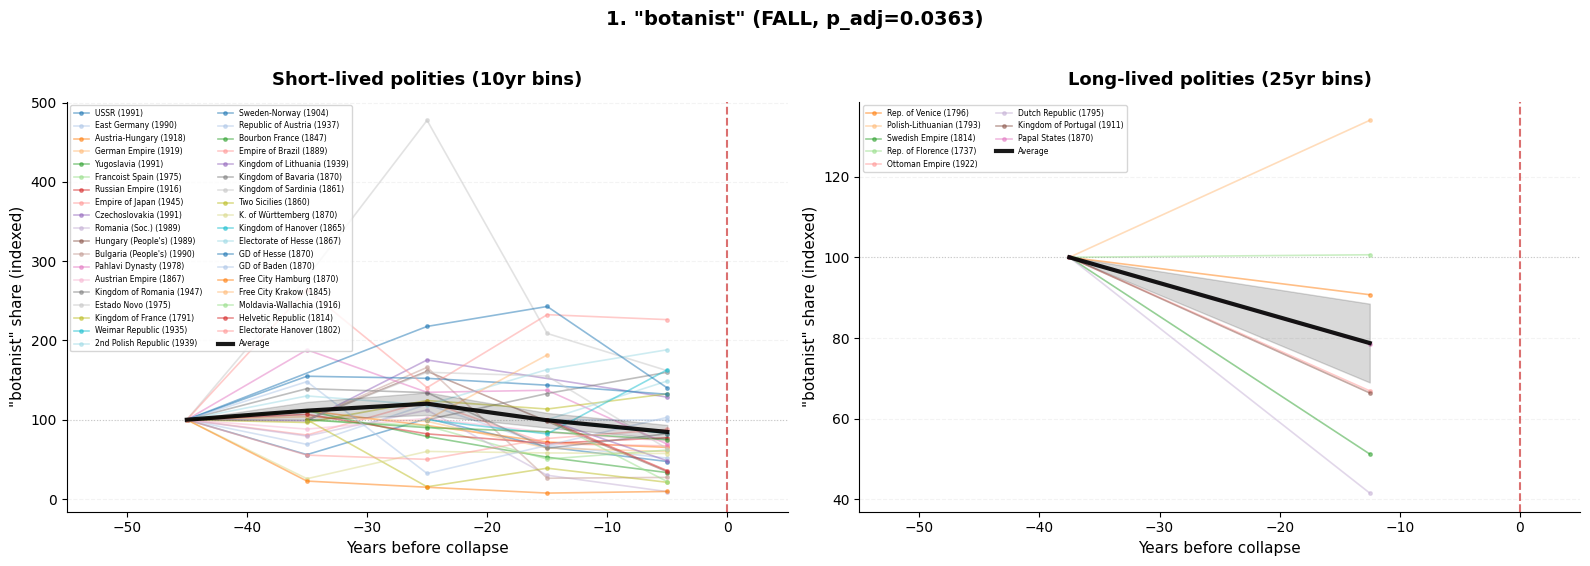

In [ ]:
cmap_vis = plt.cm.tab20

def plot_occupation_signal(result, rank_label):
    occ       = result['occupation']
    direction = result['direction']
    pval_c    = result['pvalue_corrected']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

    for ax, group_label, group, bin_w in [
        (ax1, 'Short-lived polities (10yr bins)',
         [(l, p, y) for l, p, y, t in all_polities if t == 'short'], 10),
        (ax2, 'Long-lived polities (25yr bins)',
         [(l, p, y) for l, p, y, t in all_polities if t == 'long'], 25),
    ]:
        all_xs_set = set()
        curves = []

        for i, (label, polity_name, collapse_yr) in enumerate(group):
            entries = polity_data[label]
            occ_by_bin  = defaultdict(int)
            total_by_bin = defaultdict(int)

            for year, occs in entries:
                t_rel = year - collapse_yr
                if t_rel < -50 or t_rel > 0:
                    continue
                # Relative binning: merge t_rel=0 into last negative bin
                if t_rel == 0:
                    b = -bin_w
                else:
                    b = (t_rel // bin_w) * bin_w
                    if b < -50:
                        b = -50
                total_by_bin[b] += 1
                if occ in occs:
                    occ_by_bin[b] += 1

            # Build curve: x = bin midpoint, y = share (%)
            curve = []
            for b in sorted(total_by_bin):
                if total_by_bin[b] >= 5 and occ_by_bin[b] >= 1:
                    x = b + bin_w / 2
                    share = occ_by_bin[b] / total_by_bin[b] * 100
                    curve.append((x, share))

            if len(curve) >= 2 and curve[0][1] > 0:
                xs, vs = zip(*curve)
                base = vs[0]
                vs_norm = [v / base * 100 for v in vs]
                ax.plot(xs, vs_norm, '-o', color=cmap_vis(i % 20),
                        label=f'{label} ({collapse_yr})',
                        linewidth=1.2, markersize=2.5, alpha=0.5)
                curves.append((list(xs), list(vs_norm)))
                all_xs_set.update(xs)

        # Average + SEM
        if curves:
            all_xs = sorted(all_xs_set)
            matrix = []
            for xs, vs in curves:
                x_to_v = dict(zip(xs, vs))
                row = [x_to_v.get(x, np.nan) for x in all_xs]
                matrix.append(row)
            arr = np.array(matrix)
            n_valid = np.sum(~np.isnan(arr), axis=0)
            mask = n_valid >= 3
            mean_v = np.nanmean(arr, axis=0)
            sem_v  = np.nanstd(arr, axis=0) / np.sqrt(np.where(n_valid > 0, n_valid, 1))

            xs_m  = np.array(all_xs)[mask]
            mean_m = mean_v[mask]
            sem_m  = sem_v[mask]

            ax.plot(xs_m, mean_m, '-', color='black', linewidth=3, alpha=0.9,
                    label='Average', zorder=10)
            ax.fill_between(xs_m, mean_m - sem_m, mean_m + sem_m,
                            color='black', alpha=0.15, zorder=9)

        # Styling (matches fig_societal_trends.ipynb)
        ax.axvline(0, color='#cc3333', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.axhline(100, color='#888888', linestyle=':', linewidth=0.8, alpha=0.4)
        ax.set_xlim(-55, 5)
        ax.set_xlabel('Years before collapse', fontsize=11)
        ax.set_ylabel(f'"{occ}" share (indexed)', fontsize=11)
        ax.set_title(group_label, fontsize=13, fontweight='bold', pad=12)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=5.5, loc='best', ncol=2, frameon=True, edgecolor='#cccccc')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.15, linestyle='--')

    p_str = f'{pval_c:.4f}' if pval_c >= 0.0001 else f'{pval_c:.2e}'
    fig.suptitle(f'{rank_label}. "{occ}" ({direction}, p_adj={p_str})',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

if len(results) >= 1:
    plot_occupation_signal(results[0], 1)


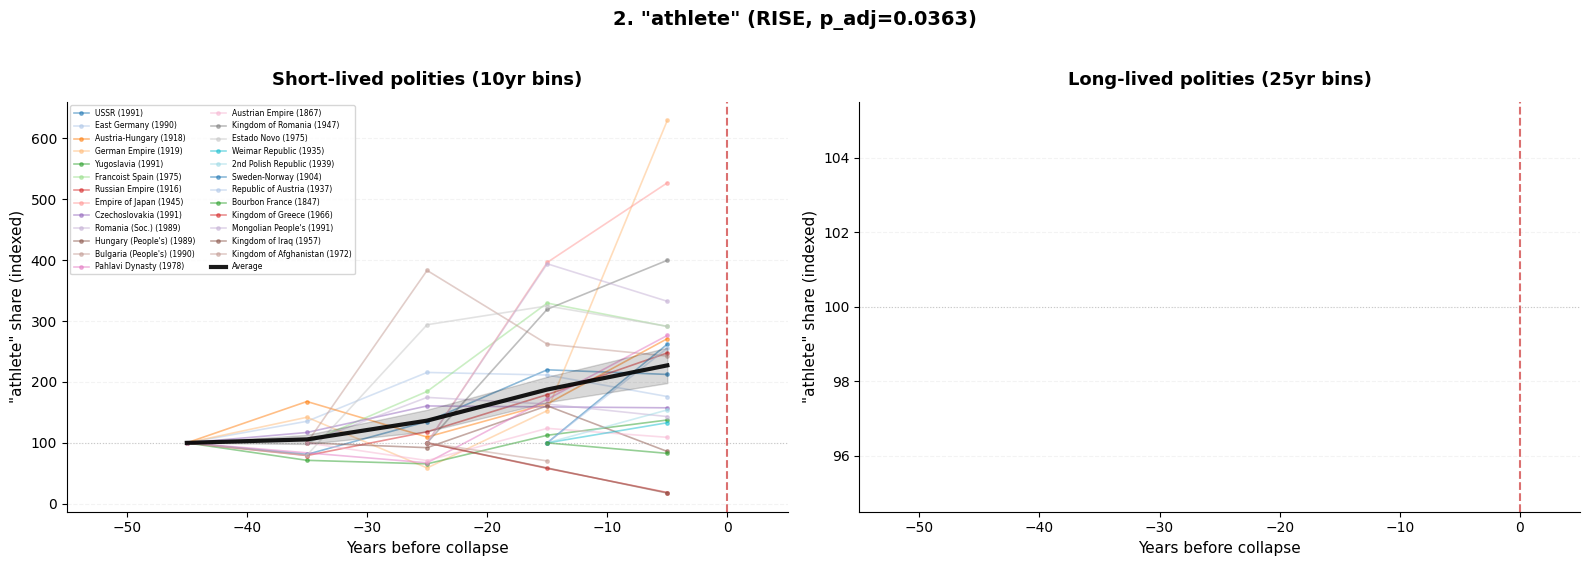

In [ ]:
if len(results) >= 2:
    plot_occupation_signal(results[1], 2)


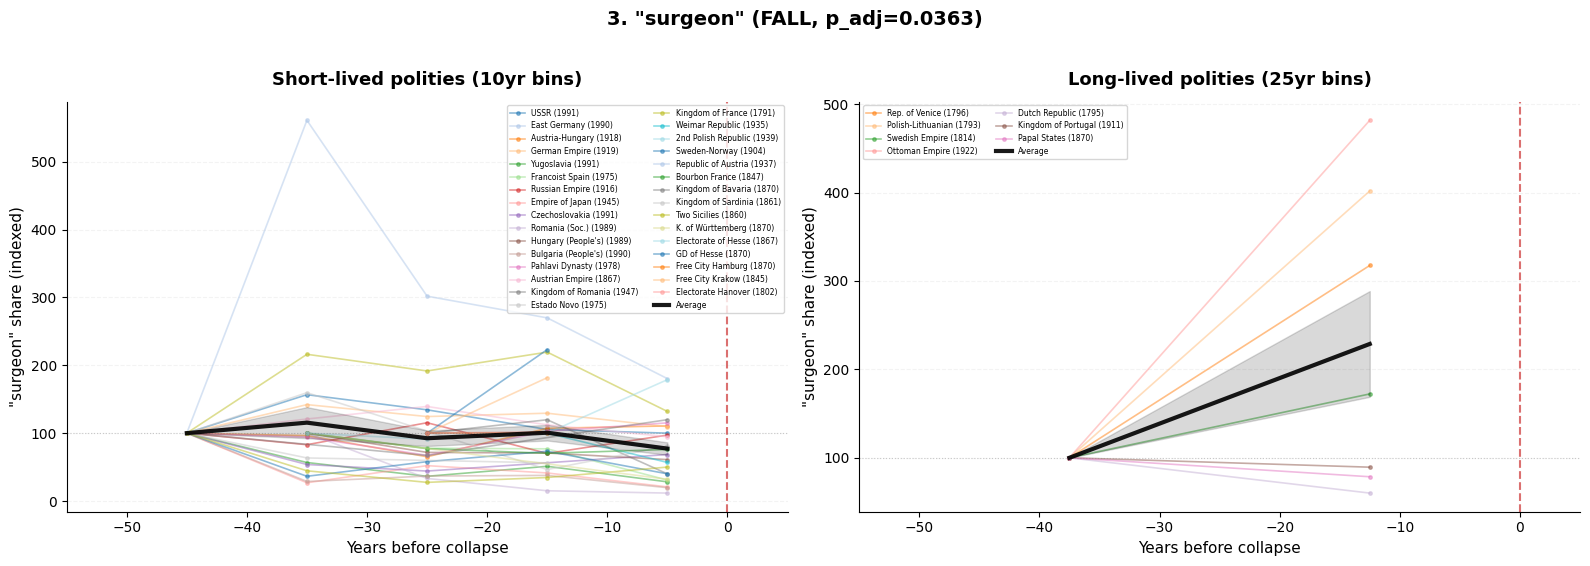

In [ ]:
if len(results) >= 3:
    plot_occupation_signal(results[2], 3)


In [ ]:
# ===== DIFFERENCE-IN-DIFFERENCES CONTROL FOR SECULAR TRENDS =====
# For each collapsed polity's 50yr window, compute the same occupation delta
# in non-collapsed polities alive during the same calendar years.
# adjusted_delta = collapsed_delta - background_delta

conn2 = sqlite3.connect(DB)
conn2.execute('PRAGMA cache_size=-500000')

collapsed_names_list = list(set(pn for _, pn, _, _ in all_polities))

window_to_polities = defaultdict(list)
for label, pn, collapse_yr, ptype in all_polities:
    window_to_polities[(collapse_yr - 50, collapse_yr)].append(label)

placeholders = ','.join(['?'] * len(collapsed_names_list))

print(f'Loading background data for {len(window_to_polities)} unique time windows...')

bg_data = {}
for (yr_start, yr_end), labels in sorted(window_to_polities.items()):
    query = f'''
        SELECT impact_year, occupations
        FROM consolidate
        WHERE polity_name NOT IN ({placeholders})
          AND impact_year IS NOT NULL
          AND occupations IS NOT NULL
          AND impact_year >= ? AND impact_year <= ?
    '''
    params = collapsed_names_list + [yr_start, yr_end]

    early_total = late_total = 0
    early_occ = Counter()
    late_occ = Counter()
    bin_data = {10: defaultdict(Counter), 25: defaultdict(Counter)}

    n_rows = 0
    for year, occs_str in conn2.execute(query, params):
        n_rows += 1
        occs = [o.strip() for o in occs_str.split('; ') if o.strip()]
        t_rel = year - yr_end

        if -50 <= t_rel <= -26:
            early_total += 1
            for o in occs:
                early_occ[o] += 1
        elif -25 <= t_rel <= 0:
            late_total += 1
            for o in occs:
                late_occ[o] += 1

        if -50 <= t_rel <= 0:
            for bw in (10, 25):
                b = -bw if t_rel == 0 else max((t_rel // bw) * bw, -50)
                x = b + bw / 2
                bin_data[bw][x]['_total'] += 1
                for o in occs:
                    bin_data[bw][x][o] += 1

    bg_data[(yr_start, yr_end)] = {
        'early_total': early_total, 'late_total': late_total,
        'early_occ': early_occ, 'late_occ': late_occ,
        'bin_10': dict(bin_data[10]), 'bin_25': dict(bin_data[25]),
    }
    print(f'  [{yr_start},{yr_end}]: {n_rows:>9,} bg indiv  '
          f'(early={early_total:,} late={late_total:,})  -> {", ".join(labels[:3])}'
          f'{"..." if len(labels) > 3 else ""}')

conn2.close()

# ---- Run controlled Wilcoxon test ----
results_ctrl = []

for occ in top_occs:
    adj_deltas = []
    polity_labels = []

    for label, polity_name, collapse_yr, ptype in all_polities:
        entries = polity_data[label]
        window = (collapse_yr - 50, collapse_yr)
        bg = bg_data.get(window)
        if bg is None or bg['early_total'] < 10 or bg['late_total'] < 10:
            continue

        et = eo = lt = lo = 0
        for year, occs in entries:
            t_rel = year - collapse_yr
            if -50 <= t_rel <= -26:
                et += 1
                if occ in occs: eo += 1
            elif -25 <= t_rel <= 0:
                lt += 1
                if occ in occs: lo += 1

        if eo < 3 or lo < 3:
            continue

        c_delta = (lo / lt - eo / et) * 100
        bg_early_share = bg['early_occ'].get(occ, 0) / bg['early_total'] * 100
        bg_late_share  = bg['late_occ'].get(occ, 0)  / bg['late_total']  * 100
        b_delta = bg_late_share - bg_early_share

        adj_deltas.append(c_delta - b_delta)
        polity_labels.append(label)

    if len(adj_deltas) >= 8:
        arr = np.array(adj_deltas)
        if np.all(arr == 0):
            continue
        try:
            stat, pval = wilcoxon(arr)
        except ValueError:
            continue

        mean_d = np.mean(arr)
        results_ctrl.append({
            'occupation':   occ,
            'direction':    'RISE' if mean_d > 0 else 'FALL',
            'n_polities':   len(adj_deltas),
            'mean_delta':   mean_d,
            'median_delta': np.median(arr),
            'pvalue':       pval,
            'consistency':  np.mean([(d > 0) == (mean_d > 0) for d in arr]) * 100,
            'deltas':       adj_deltas,
            'polity_labels': polity_labels,
        })

pvals_c = np.array([r['pvalue'] for r in results_ctrl])
adj_p = bh_correction(pvals_c)
for r, ap in zip(results_ctrl, adj_p):
    r['pvalue_corrected'] = ap
results_ctrl.sort(key=lambda x: x['pvalue_corrected'])

n_sig_ctrl = sum(1 for r in results_ctrl if r['pvalue_corrected'] < 0.05)
print(f'\n=== Background-controlled test (difference-in-differences) ===')
print(f'Tested: {len(results_ctrl)} occupations')
print(f'Significant after BH correction (q < 0.05): {n_sig_ctrl}')

# ---- Comparison table: raw vs controlled ----
raw_rank = {r['occupation']: i+1 for i, r in enumerate(results)}

rows_cmp = []
for i, r in enumerate(results_ctrl[:20]):
    occ = r['occupation']
    rr = raw_rank.get(occ, None)
    raw_dir = next((x['direction'] for x in results if x['occupation'] == occ), '?')
    raw_p = next((x['pvalue_corrected'] for x in results if x['occupation'] == occ), None)
    rows_cmp.append({
        'Ctrl Rank':  i + 1,
        'Occupation':  occ,
        'Ctrl dir':   r['direction'],
        'Ctrl delta': f'{r["mean_delta"]:+.2f}',
        'Ctrl p_adj':  f'{r["pvalue_corrected"]:.4f}' if r['pvalue_corrected'] >= 1e-4
                       else f'{r["pvalue_corrected"]:.2e}',
        'Raw Rank':    rr if rr else '-',
        'Raw dir':     raw_dir,
        'Raw p_adj':   f'{raw_p:.4f}' if raw_p and raw_p >= 1e-4
                       else (f'{raw_p:.2e}' if raw_p else '-'),
    })

df_cmp = pd.DataFrame(rows_cmp).set_index('Ctrl Rank')
print('\nTop 20 controlled results vs raw:\n')
print(df_cmp.to_string())


Loading background data for 49 unique time windows...
  [173,223]:       558 bg indiv  (early=281 late=277)  -> Han Dynasty


  [704,754]:       308 bg indiv  (early=98 late=210)  -> Umayyad Caliphate
  [860,910]:       644 bg indiv  (early=284 late=360)  -> Tang Dynasty


  [977,1027]:       947 bg indiv  (early=572 late=375)  -> Northern Song


  [1228,1278]:     1,867 bg indiv  (early=1,078 late=789)  -> Southern Song
  [1243,1293]:     1,811 bg indiv  (early=709 late=1,102)  -> Mongol Empire


  [1594,1644]:    14,917 bg indiv  (early=7,244 late=7,673)  -> Ming Dynasty


...

  [1928,1978]:   775,934 bg indiv  (early=282,198 late=493,736)  -> Pahlavi Dynasty


  [1939,1989]: 1,012,087 bg indiv  (early=342,618 late=669,469)  -> Romania (Soc.), Hungary (People's)


  [1940,1990]: 1,035,406 bg indiv  (early=349,907 late=685,499)  -> East Germany, Bulgaria (People's)


  [1941,1991]: 1,063,404 bg indiv  (early=360,286 late=703,118)  -> USSR, Yugoslavia, Czechoslovakia...



=== Background-controlled test (difference-in-differences) ===
Tested: 249 occupations
Significant after BH correction (q < 0.05): 0

Top 20 controlled results vs raw:

                    Occupation Ctrl dir Ctrl delta Ctrl p_adj  Raw Rank Raw dir Raw p_adj
Ctrl Rank                                                                                
1                       lawyer     RISE      +0.98     0.0523        94    RISE    0.2662
2                        actor     FALL      -0.38     0.2702       206    RISE    0.8201
3                     musician     FALL      -0.18     0.2702       236    RISE    0.9726
4                       author     FALL      -0.29     0.2702       116    FALL    0.3624
5                        coach     RISE      +0.22     0.2702        26    RISE    0.0695
6                   agronomist     FALL      -0.20     0.2702        15    FALL    0.0599
7                sport cyclist     RISE      +0.17     0.2702        16    RISE    0.0599
8                   

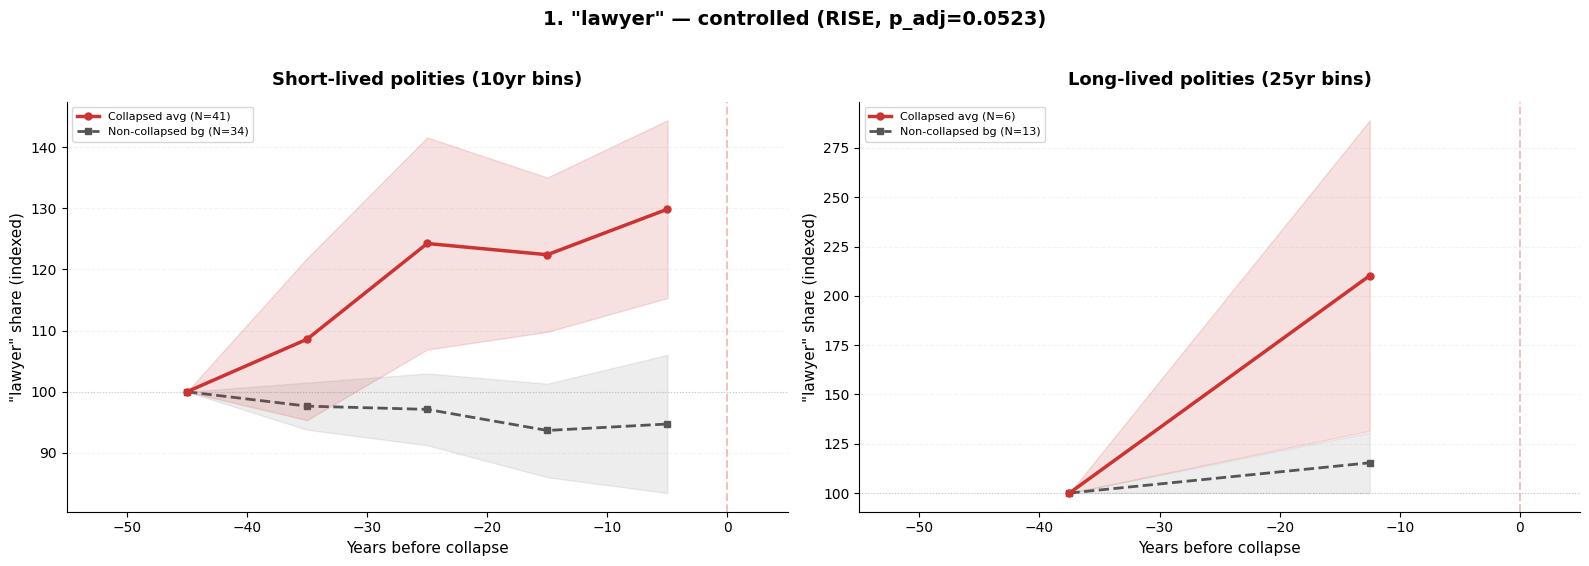

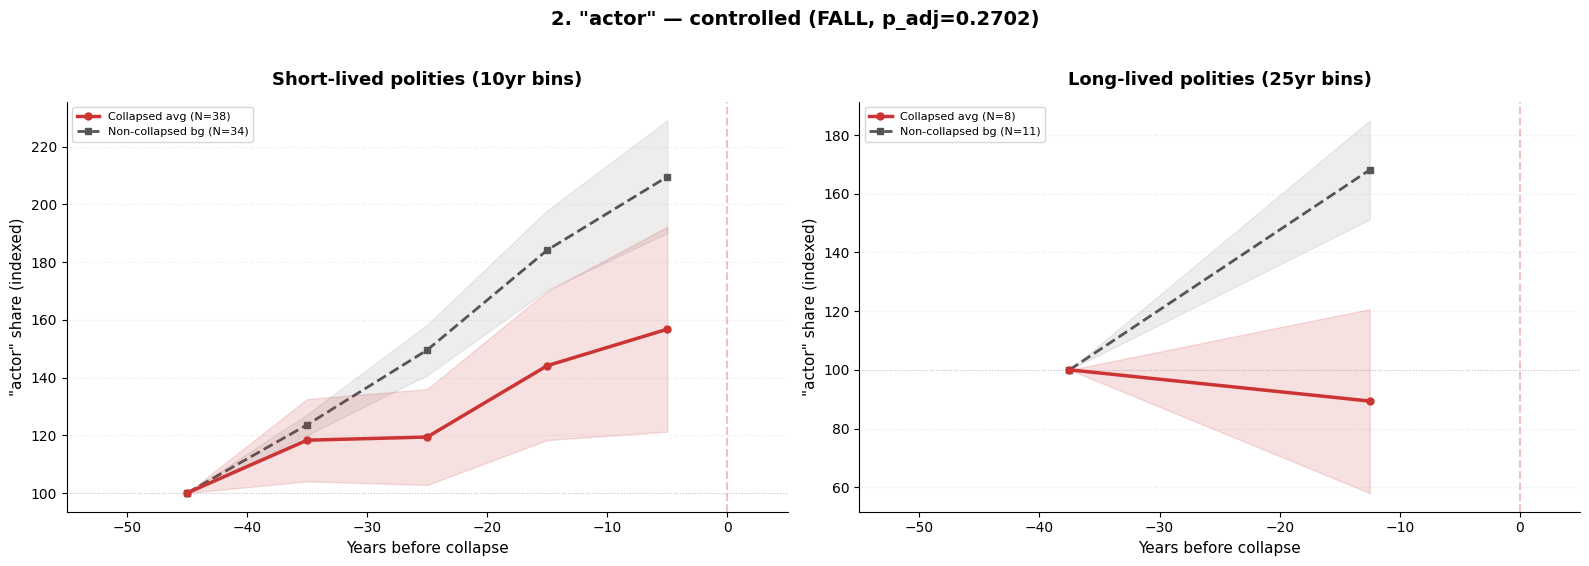

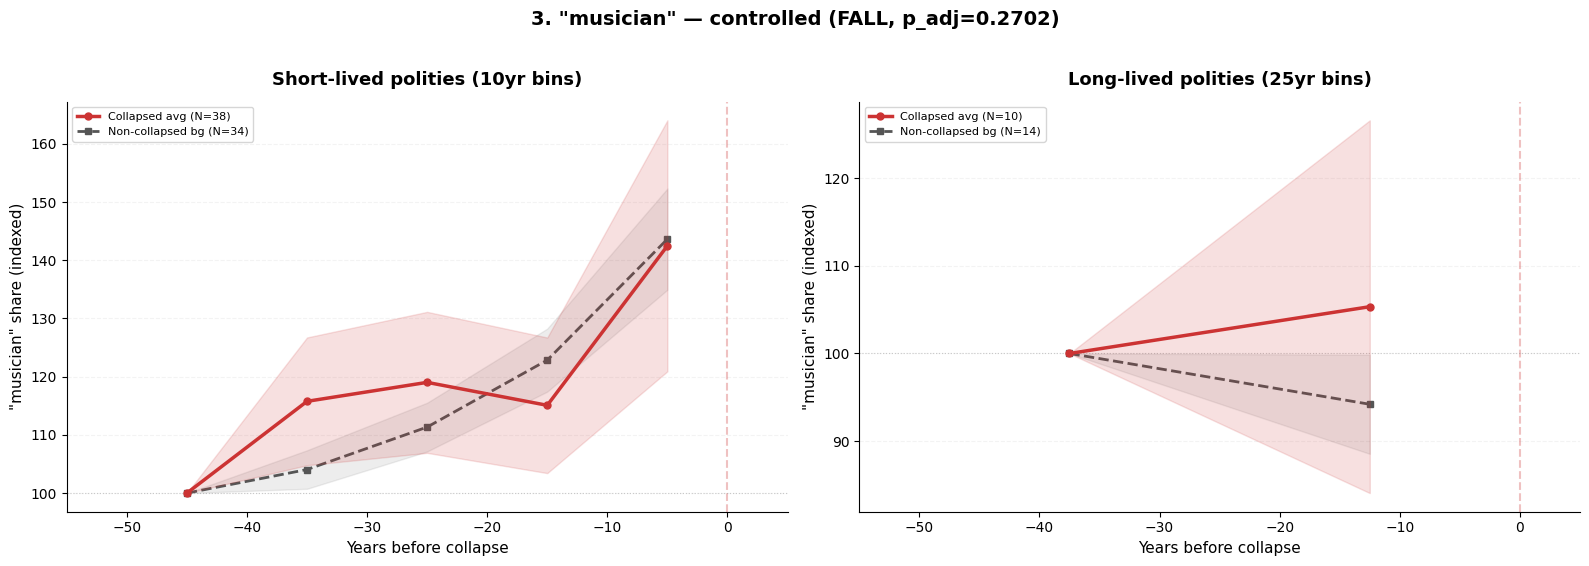

In [ ]:
# ===== VISUALIZATION: Collapsed vs Non-Collapsed Background =====

def plot_controlled(result, rank_label):
    occ       = result['occupation']
    direction = result['direction']
    pval_c    = result['pvalue_corrected']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

    for ax, group_label, group, bin_w in [
        (ax1, 'Short-lived polities (10yr bins)',
         [(l, p, y) for l, p, y, t in all_polities if t == 'short'], 10),
        (ax2, 'Long-lived polities (25yr bins)',
         [(l, p, y) for l, p, y, t in all_polities if t == 'long'], 25),
    ]:
        bin_key = f'bin_{bin_w}'

        # ---- Collapsed polities: per-polity curves + average ----
        c_curves = []
        for i, (label, polity_name, collapse_yr) in enumerate(group):
            entries = polity_data[label]
            occ_by_bin  = defaultdict(int)
            total_by_bin = defaultdict(int)
            for year, occs in entries:
                t_rel = year - collapse_yr
                if t_rel < -50 or t_rel > 0:
                    continue
                b = -bin_w if t_rel == 0 else max((t_rel // bin_w) * bin_w, -50)
                x = b + bin_w / 2
                total_by_bin[x] += 1
                if occ in occs:
                    occ_by_bin[x] += 1
            curve = []
            for x in sorted(total_by_bin):
                if total_by_bin[x] >= 5 and occ_by_bin[x] >= 1:
                    curve.append((x, occ_by_bin[x] / total_by_bin[x] * 100))
            if len(curve) >= 2 and curve[0][1] > 0:
                xs, vs = zip(*curve)
                base = vs[0]
                c_curves.append((list(xs), [v / base * 100 for v in vs]))

        # ---- Background: one curve per time window ----
        b_curves = []
        seen_windows = set()
        for label, polity_name, collapse_yr in group:
            window = (collapse_yr - 50, collapse_yr)
            if window in seen_windows:
                continue
            seen_windows.add(window)
            bg = bg_data.get(window)
            if bg is None:
                continue
            bd = bg[bin_key]
            curve = []
            for x in sorted(bd):
                total = bd[x]['_total']
                oc    = bd[x].get(occ, 0)
                if total >= 5 and oc >= 1:
                    curve.append((x, oc / total * 100))
            if len(curve) >= 2 and curve[0][1] > 0:
                xs, vs = zip(*curve)
                base = vs[0]
                b_curves.append((list(xs), [v / base * 100 for v in vs]))

        # Helper: average + SEM from list of curves
        def avg_sem(curves_list, all_xs, min_n=2):
            if not curves_list:
                return None, None, None
            mat = []
            for xs, vs in curves_list:
                d = dict(zip(xs, vs))
                mat.append([d.get(x, np.nan) for x in all_xs])
            arr = np.array(mat)
            nv = np.sum(~np.isnan(arr), axis=0)
            mask = nv >= min_n
            mean = np.nanmean(arr, axis=0)
            sem  = np.nanstd(arr, axis=0) / np.sqrt(np.where(nv > 0, nv, 1))
            return mean, sem, mask

        all_xs_set = set()
        for xs, _ in c_curves + b_curves:
            all_xs_set.update(xs)
        all_xs = sorted(all_xs_set)

        if all_xs:
            # Plot collapsed average
            cm, cs, cmask = avg_sem(c_curves, all_xs)
            if cm is not None and cmask.any():
                xc = np.array(all_xs)[cmask]
                ax.plot(xc, cm[cmask], '-o', color='#cc3333', linewidth=2.5,
                        markersize=5, label=f'Collapsed avg (N={len(c_curves)})',
                        zorder=10)
                ax.fill_between(xc, cm[cmask] - cs[cmask], cm[cmask] + cs[cmask],
                                color='#cc3333', alpha=0.15, zorder=9)

            # Plot background average
            bm, bs, bmask = avg_sem(b_curves, all_xs)
            if bm is not None and bmask.any():
                xb = np.array(all_xs)[bmask]
                ax.plot(xb, bm[bmask], '--s', color='#555555', linewidth=2,
                        markersize=4, label=f'Non-collapsed bg (N={len(b_curves)})',
                        zorder=8)
                ax.fill_between(xb, bm[bmask] - bs[bmask], bm[bmask] + bs[bmask],
                                color='#555555', alpha=0.1, zorder=7)

        ax.axvline(0, color='#cc3333', linestyle='--', linewidth=1.5, alpha=0.3)
        ax.axhline(100, color='#888888', linestyle=':', linewidth=0.8, alpha=0.4)
        ax.set_xlim(-55, 5)
        ax.set_xlabel('Years before collapse', fontsize=11)
        ax.set_ylabel(f'"{occ}" share (indexed)', fontsize=11)
        ax.set_title(group_label, fontsize=13, fontweight='bold', pad=12)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=8, loc='best', frameon=True, edgecolor='#cccccc')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.15, linestyle='--')

    p_str = f'{pval_c:.4f}' if pval_c >= 0.0001 else f'{pval_c:.2e}'
    fig.suptitle(f'{rank_label}. "{occ}" — controlled ({direction}, p_adj={p_str})',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

for i in range(min(3, len(results_ctrl))):
    plot_controlled(results_ctrl[i], i + 1)

conn.close()


In [ ]:
# ===== LAWYER DEEP-DIVE =====
# Short-lived: 50yr window (same as before)
# Long-lived: 300yr window to see the long-run trajectory

occ_focus = 'lawyer'
WINDOW_LONG = 300

conn3 = sqlite3.connect(DB)
conn3.execute('PRAGMA cache_size=-500000')

collapsed_names_list = list(set(pn for _, pn, _, _ in all_polities))
placeholders = ','.join(['?'] * len(collapsed_names_list))

# ---- Load 300yr collapsed-polity data for long-lived ----
lawyer_long = {}  # label -> [(year, is_lawyer)]
print('Long-lived polities — 300yr window:')
for label, pn, collapse_yr in long_lived:
    rows = conn3.execute('''
        SELECT impact_year, occupations FROM consolidate
        WHERE polity_name = ? AND impact_year IS NOT NULL AND occupations IS NOT NULL
          AND impact_year >= ? AND impact_year <= ?
    ''', (pn, collapse_yr - WINDOW_LONG, collapse_yr)).fetchall()
    parsed = [(yr, occ_focus in occs.split('; ')) for yr, occs in rows]
    lawyer_long[label] = parsed
    n_law = sum(1 for _, h in parsed if h)
    print(f'  {label:25s} [{collapse_yr-WINDOW_LONG},{collapse_yr}]: '
          f'{len(parsed):>5,} indiv, {n_law:>3} lawyers')

# ---- Load 300yr background for long-lived ----
bg_long = {}
print('\nBackground (300yr windows):')
for label, pn, collapse_yr in long_lived:
    yr_s, yr_e = collapse_yr - WINDOW_LONG, collapse_yr
    if (yr_s, yr_e) in bg_long:
        continue
    query = f'''
        SELECT impact_year, occupations FROM consolidate
        WHERE polity_name NOT IN ({placeholders})
          AND impact_year IS NOT NULL AND occupations IS NOT NULL
          AND impact_year >= ? AND impact_year <= ?
    '''
    params = collapsed_names_list + [yr_s, yr_e]

    mid = yr_s + WINDOW_LONG // 2
    et = el = lt = ll = 0
    bin_total = defaultdict(int)
    bin_lawyer = defaultdict(int)

    n_rows = 0
    for year, occs_str in conn3.execute(query, params):
        n_rows += 1
        has = occ_focus in occs_str.split('; ')
        if year <= mid:
            et += 1
            if has: el += 1
        else:
            lt += 1
            if has: ll += 1
        t_rel = year - yr_e
        b = -25 if t_rel == 0 else max((t_rel // 25) * 25, -WINDOW_LONG)
        x = b + 12.5
        bin_total[x] += 1
        if has: bin_lawyer[x] += 1

    bg_long[(yr_s, yr_e)] = {
        'et': et, 'el': el, 'lt': lt, 'll': ll,
        'bin_total': dict(bin_total), 'bin_lawyer': dict(bin_lawyer),
    }
    print(f'  [{yr_s},{yr_e}]: {n_rows:>8,} bg indiv')

conn3.close()

# ---- Stats: short-lived (reuse existing 50yr data from cells 0-6) ----
short_ctrl_deltas = []
short_raw_deltas = []
short_labels_ok = []

for label, pn, collapse_yr in short_lived:
    entries = polity_data[label]
    window = (collapse_yr - 50, collapse_yr)
    bg = bg_data.get(window)

    et = eo = lt = lo = 0
    for year, occs in entries:
        t_rel = year - collapse_yr
        if -50 <= t_rel <= -26:
            et += 1
            if occ_focus in occs: eo += 1
        elif -25 <= t_rel <= 0:
            lt += 1
            if occ_focus in occs: lo += 1

    if eo < 2 or lo < 2 or et == 0 or lt == 0:
        continue
    c_d = (lo/lt - eo/et) * 100
    short_raw_deltas.append(c_d)

    if bg and bg['early_total'] >= 10 and bg['late_total'] >= 10:
        bg_es = bg['early_occ'].get(occ_focus, 0) / bg['early_total'] * 100
        bg_ls = bg['late_occ'].get(occ_focus, 0) / bg['late_total'] * 100
        short_ctrl_deltas.append(c_d - (bg_ls - bg_es))
    else:
        short_ctrl_deltas.append(c_d)
    short_labels_ok.append(label)

# ---- Stats: long-lived (300yr window) ----
long_ctrl_deltas = []
long_raw_deltas = []
long_labels_ok = []

for label, pn, collapse_yr in long_lived:
    data = lawyer_long[label]
    mid = collapse_yr - WINDOW_LONG // 2

    et = eo = lt = lo = 0
    for year, has in data:
        if year <= mid:
            et += 1
            if has: eo += 1
        else:
            lt += 1
            if has: lo += 1

    if eo < 2 or lo < 2 or et == 0 or lt == 0:
        continue
    c_d = (lo/lt - eo/et) * 100
    long_raw_deltas.append(c_d)

    key = (collapse_yr - WINDOW_LONG, collapse_yr)
    bg = bg_long.get(key)
    if bg and bg['et'] >= 10 and bg['lt'] >= 10:
        bg_es = bg['el'] / bg['et'] * 100
        bg_ls = bg['ll'] / bg['lt'] * 100
        long_ctrl_deltas.append(c_d - (bg_ls - bg_es))
    else:
        long_ctrl_deltas.append(c_d)
    long_labels_ok.append(label)

# ---- Print summary ----
print(f'\n{"="*60}')
print(f'LAWYER — Statistical Summary')
print(f'{"="*60}')

print(f'\nShort-lived (50yr, early=[T-50,T-26] vs late=[T-25,T-0]):')
print(f'  Polities with data: {len(short_labels_ok)}')
for l, rd, cd in zip(short_labels_ok, short_raw_deltas, short_ctrl_deltas):
    print(f'    {l:25s}  raw={rd:+.2f}pp  ctrl={cd:+.2f}pp')
if len(short_ctrl_deltas) >= 5:
    arr = np.array(short_ctrl_deltas)
    try:
        _, p = wilcoxon(arr)
        print(f'  Controlled Wilcoxon p = {p:.4f}, mean = {np.mean(arr):+.2f}pp, '
              f'median = {np.median(arr):+.2f}pp')
    except ValueError:
        print('  Wilcoxon: cannot compute')

print(f'\nLong-lived (300yr, early=[T-300,T-151] vs late=[T-150,T-0]):')
print(f'  Polities with data: {len(long_labels_ok)}')
for l, rd, cd in zip(long_labels_ok, long_raw_deltas, long_ctrl_deltas):
    print(f'    {l:25s}  raw={rd:+.2f}pp  ctrl={cd:+.2f}pp')
if len(long_ctrl_deltas) >= 5:
    arr = np.array(long_ctrl_deltas)
    try:
        _, p = wilcoxon(arr)
        print(f'  Controlled Wilcoxon p = {p:.4f}, mean = {np.mean(arr):+.2f}pp, '
              f'median = {np.median(arr):+.2f}pp')
    except ValueError:
        print('  Wilcoxon: cannot compute')


Long-lived polities — 300yr window:


  Ming Dynasty              [1344,1644]: 10,742 indiv,   0 lawyers
  Southern Song             [978,1278]: 2,044 indiv,   0 lawyers


  Rep. of Venice            [1496,1796]: 3,474 indiv,  29 lawyers


  Polish-Lithuanian         [1493,1793]: 4,480 indiv,  16 lawyers


  Swedish Empire            [1514,1814]: 10,586 indiv,   9 lawyers
  Rep. of Florence          [1437,1737]: 1,879 indiv,   7 lawyers
  Mongol Empire             [993,1293]:   553 indiv,   1 lawyers


...

  [1495,1795]:  108,205 bg indiv


  [1568,1868]:  247,871 bg indiv


  [1570,1870]:  254,768 bg indiv


  [1597,1897]:  362,715 bg indiv
  [610,910]:    3,108 bg indiv
  [-77,223]:    2,840 bg indiv
  [454,754]:    3,171 bg indiv
  [727,1027]:    4,365 bg indiv



LAWYER — Statistical Summary

Short-lived (50yr, early=[T-50,T-26] vs late=[T-25,T-0]):
  Polities with data: 31
    USSR                       raw=-0.06pp  ctrl=+0.18pp
    East Germany               raw=+0.35pp  ctrl=+0.61pp
    Austria-Hungary            raw=-1.07pp  ctrl=+0.70pp
    German Empire              raw=+0.31pp  ctrl=+2.16pp
    Yugoslavia                 raw=+0.12pp  ctrl=+0.36pp
    Francoist Spain            raw=+0.28pp  ctrl=+0.88pp
    Russian Empire             raw=+0.63pp  ctrl=+2.16pp
    Empire of Japan            raw=-2.12pp  ctrl=-0.97pp
    Czechoslovakia             raw=-0.08pp  ctrl=+0.16pp
    Romania (Soc.)             raw=-0.35pp  ctrl=-0.08pp
    Hungary (People's)         raw=+0.38pp  ctrl=+0.65pp
    Bulgaria (People's)        raw=-0.09pp  ctrl=+0.16pp
    Pahlavi Dynasty            raw=-0.66pp  ctrl=-0.15pp
    Austrian Empire            raw=+1.19pp  ctrl=+1.44pp
    Kingdom of Romania         raw=-2.09pp  ctrl=-1.07pp
    Estado Novo                

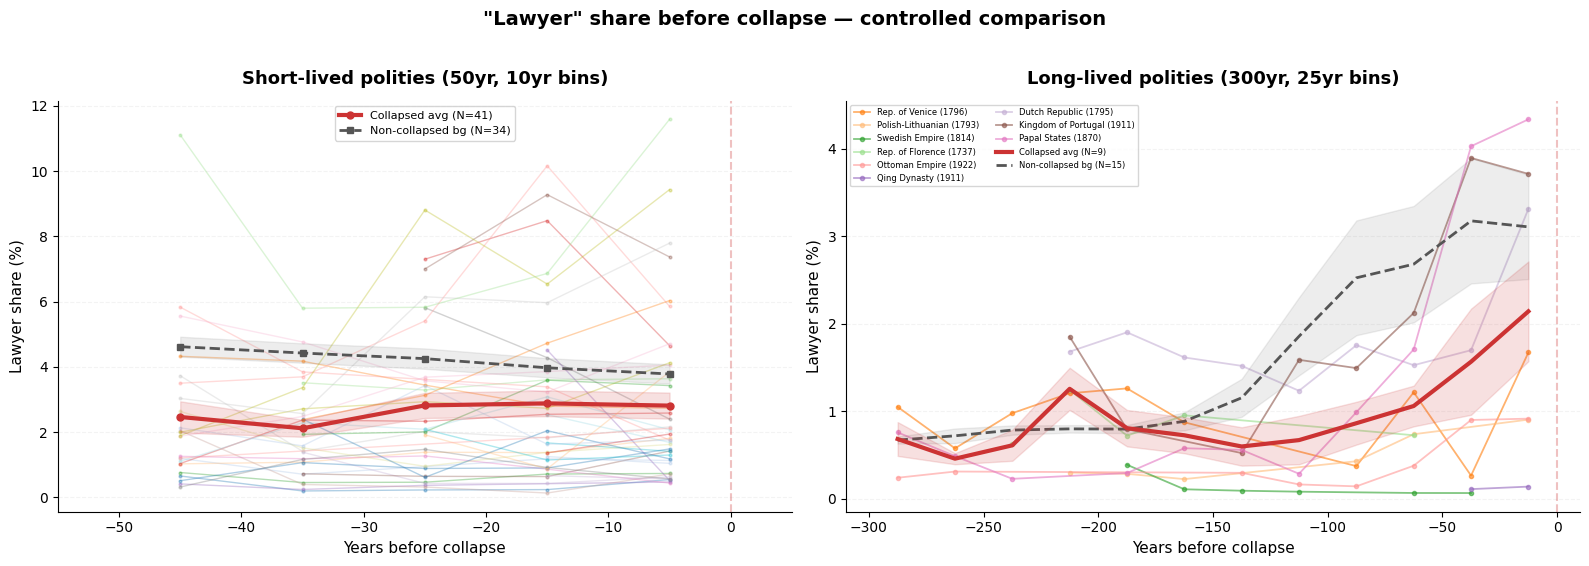

In [ ]:
# ===== LAWYER VISUALIZATION — raw share (%) =====

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
cmap_l = plt.cm.tab20

# ---- LEFT PANEL: Short-lived, 50yr, 10yr bins ----
ax = ax1
bin_w = 10
c_curves = []
for i, (label, pn, collapse_yr) in enumerate(short_lived):
    entries = polity_data[label]
    occ_by_b = defaultdict(int)
    tot_by_b = defaultdict(int)
    for year, occs in entries:
        t_rel = year - collapse_yr
        if t_rel < -50 or t_rel > 0:
            continue
        b = -bin_w if t_rel == 0 else max((t_rel // bin_w) * bin_w, -50)
        x = b + bin_w / 2
        tot_by_b[x] += 1
        if occ_focus in occs:
            occ_by_b[x] += 1
    curve = [(x, occ_by_b[x] / tot_by_b[x] * 100)
             for x in sorted(tot_by_b) if tot_by_b[x] >= 5 and occ_by_b[x] >= 1]
    if len(curve) >= 2:
        xs, vs = zip(*curve)
        ax.plot(xs, vs, '-o', color=cmap_l(i % 20), lw=1, ms=2, alpha=0.35)
        c_curves.append((list(xs), list(vs)))

# Background curves (short-lived, 50yr)
b_curves = []
seen = set()
for label, pn, collapse_yr in short_lived:
    w = (collapse_yr - 50, collapse_yr)
    if w in seen: continue
    seen.add(w)
    bg = bg_data.get(w)
    if bg is None: continue
    bd = bg['bin_10']
    curve = [(x, bd[x].get(occ_focus, 0) / bd[x]['_total'] * 100)
             for x in sorted(bd) if bd[x]['_total'] >= 5 and bd[x].get(occ_focus, 0) >= 1]
    if len(curve) >= 2:
        xs, vs = zip(*curve)
        b_curves.append((list(xs), list(vs)))

def avg_sem(curves_list, all_xs, min_n=2):
    if not curves_list:
        return None, None, None
    mat = []
    for xs, vs in curves_list:
        d = dict(zip(xs, vs))
        mat.append([d.get(x, np.nan) for x in all_xs])
    arr = np.array(mat)
    nv = np.sum(~np.isnan(arr), axis=0)
    mask = nv >= min_n
    mean = np.nanmean(arr, axis=0)
    sem  = np.nanstd(arr, axis=0) / np.sqrt(np.where(nv > 0, nv, 1))
    return mean, sem, mask

all_xs = sorted(set(x for xs, _ in c_curves + b_curves for x in xs))
if all_xs:
    cm, cs, cmask = avg_sem(c_curves, all_xs)
    if cm is not None and cmask.any():
        xc = np.array(all_xs)[cmask]
        ax.plot(xc, cm[cmask], '-o', color='#cc3333', lw=3, ms=5,
                label=f'Collapsed avg (N={len(c_curves)})', zorder=10)
        ax.fill_between(xc, cm[cmask]-cs[cmask], cm[cmask]+cs[cmask],
                        color='#cc3333', alpha=0.15, zorder=9)
    bm, bs, bmask = avg_sem(b_curves, all_xs)
    if bm is not None and bmask.any():
        xb = np.array(all_xs)[bmask]
        ax.plot(xb, bm[bmask], '--s', color='#555555', lw=2, ms=4,
                label=f'Non-collapsed bg (N={len(b_curves)})', zorder=8)
        ax.fill_between(xb, bm[bmask]-bs[bmask], bm[bmask]+bs[bmask],
                        color='#555555', alpha=0.1, zorder=7)

ax.axvline(0, color='#cc3333', ls='--', lw=1.5, alpha=0.3)
ax.set_xlim(-55, 5)
ax.set_xlabel('Years before collapse', fontsize=11)
ax.set_ylabel('Lawyer share (%)', fontsize=11)
ax.set_title('Short-lived polities (50yr, 10yr bins)', fontsize=13,
             fontweight='bold', pad=12)
h, l = ax.get_legend_handles_labels()
if h: ax.legend(fontsize=8, loc='best', frameon=True, edgecolor='#cccccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.15, ls='--')

# ---- RIGHT PANEL: Long-lived, 300yr, 25yr bins ----
ax = ax2
bin_w = 25
c_curves = []
for i, (label, pn, collapse_yr) in enumerate(long_lived):
    data = lawyer_long[label]
    occ_by_b = defaultdict(int)
    tot_by_b = defaultdict(int)
    for year, has in data:
        t_rel = year - collapse_yr
        if t_rel < -WINDOW_LONG or t_rel > 0:
            continue
        b = -bin_w if t_rel == 0 else max((t_rel // bin_w) * bin_w, -WINDOW_LONG)
        x = b + bin_w / 2
        tot_by_b[x] += 1
        if has:
            occ_by_b[x] += 1
    curve = [(x, occ_by_b[x] / tot_by_b[x] * 100)
             for x in sorted(tot_by_b) if tot_by_b[x] >= 5 and occ_by_b[x] >= 1]
    if len(curve) >= 2:
        xs, vs = zip(*curve)
        ax.plot(xs, vs, '-o', color=cmap_l(i % 20), lw=1.3, ms=3, alpha=0.6,
                label=f'{label} ({collapse_yr})')
        c_curves.append((list(xs), list(vs)))

# Background curves (long-lived, 300yr)
b_curves = []
seen = set()
for label, pn, collapse_yr in long_lived:
    w = (collapse_yr - WINDOW_LONG, collapse_yr)
    if w in seen: continue
    seen.add(w)
    bg = bg_long.get(w)
    if bg is None: continue
    bt, bl = bg['bin_total'], bg['bin_lawyer']
    curve = [(x, bl.get(x, 0) / bt[x] * 100)
             for x in sorted(bt) if bt[x] >= 5 and bl.get(x, 0) >= 1]
    if len(curve) >= 2:
        xs, vs = zip(*curve)
        b_curves.append((list(xs), list(vs)))

all_xs = sorted(set(x for xs, _ in c_curves + b_curves for x in xs))
if all_xs:
    cm, cs, cmask = avg_sem(c_curves, all_xs)
    if cm is not None and cmask.any():
        xc = np.array(all_xs)[cmask]
        ax.plot(xc, cm[cmask], '-', color='#cc3333', lw=3,
                label=f'Collapsed avg (N={len(c_curves)})', zorder=10)
        ax.fill_between(xc, cm[cmask]-cs[cmask], cm[cmask]+cs[cmask],
                        color='#cc3333', alpha=0.15, zorder=9)
    bm, bs, bmask = avg_sem(b_curves, all_xs)
    if bm is not None and bmask.any():
        xb = np.array(all_xs)[bmask]
        ax.plot(xb, bm[bmask], '--', color='#555555', lw=2,
                label=f'Non-collapsed bg (N={len(b_curves)})', zorder=8)
        ax.fill_between(xb, bm[bmask]-bs[bmask], bm[bmask]+bs[bmask],
                        color='#555555', alpha=0.1, zorder=7)

ax.axvline(0, color='#cc3333', ls='--', lw=1.5, alpha=0.3)
ax.set_xlim(-WINDOW_LONG - 10, 10)
ax.set_xlabel('Years before collapse', fontsize=11)
ax.set_ylabel('Lawyer share (%)', fontsize=11)
ax.set_title(f'Long-lived polities ({WINDOW_LONG}yr, 25yr bins)', fontsize=13,
             fontweight='bold', pad=12)
h, l = ax.get_legend_handles_labels()
if h: ax.legend(fontsize=6, loc='best', ncol=2, frameon=True, edgecolor='#cccccc')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.15, ls='--')

fig.suptitle('"Lawyer" share before collapse — controlled comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


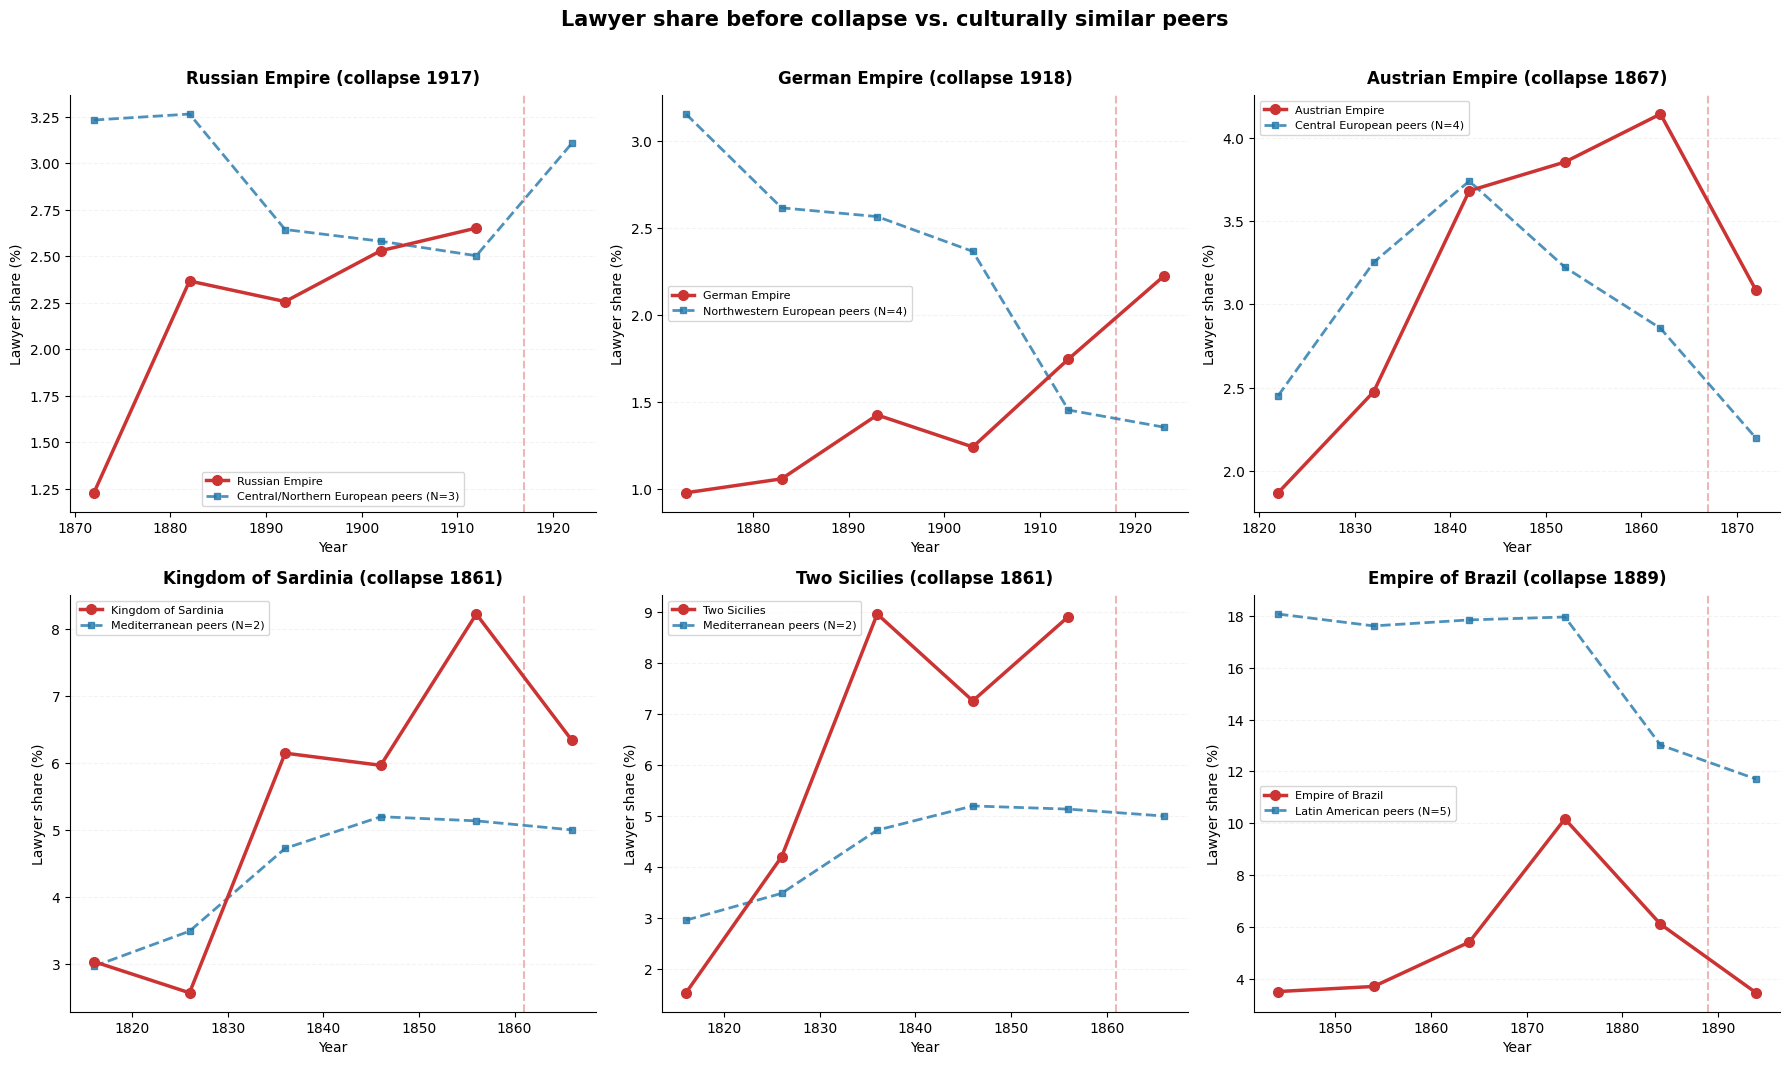

In [ ]:
# ===== CASE STUDIES: Lawyer share in collapsing vs culturally similar peers =====

import sqlite3
from collections import defaultdict

conn4 = sqlite3.connect(DB)
conn4.execute('PRAGMA cache_size=-500000')

# Each case: collapsed polity + pooled culturally similar peers
case_studies = [
    {
        'collapsed': ('Russian Empire', 'Russian Empire', 1917),
        'peers': [
            ('Austria-Hungary', 'Austria-Hungary'),
            ('Sweden-Norway', 'United Kingdoms of Sweden and Norway'),
            ('Denmark', 'Denmark-Norway'),
        ],
        'peer_label': 'Central/Northern European peers',
    },
    {
        'collapsed': ('German Empire', 'German Empire', 1918),
        'peers': [
            ('Netherlands', '(Netherlands);Netherlands'),
            ('Switzerland', 'Swiss Confederation'),
            ('Belgium', 'Kingdom of Belgium'),
            ('Denmark', 'Denmark-Norway'),
        ],
        'peer_label': 'Northwestern European peers',
    },
    {
        'collapsed': ('Austrian Empire', 'Austrian Empire', 1867),
        'peers': [
            ('Saxe-Weimar', 'Grand Duchy of Saxe-Weimar-Eisenach'),
            ('Switzerland', 'Swiss Confederation'),
            ('Belgium', 'Kingdom of Belgium'),
            ('Netherlands', '(Netherlands);Netherlands'),
        ],
        'peer_label': 'Central European peers',
    },
    {
        'collapsed': ('Kingdom of Sardinia', 'Kingdom of Sardinia', 1861),
        'peers': [
            ('Papal States', 'Papal States'),
            ('Spanish Empire', '(Kingdom of Spain);Kingdom of Spain;(Spanish Empire)'),
        ],
        'peer_label': 'Mediterranean peers',
    },
    {
        'collapsed': ('Two Sicilies', 'Kingdom of the Two Sicilies', 1861),
        'peers': [
            ('Papal States', 'Papal States'),
            ('Spanish Empire', '(Kingdom of Spain);Kingdom of Spain;(Spanish Empire)'),
        ],
        'peer_label': 'Mediterranean peers',
    },
    {
        'collapsed': ('Empire of Brazil', 'Empire of Brazil', 1889),
        'peers': [
            ('Argentina', 'Argentine Confederation'),
            ('Chile', 'Republic of Chile'),
            ('Peru', 'Republic of Peru'),
            ('Uruguay', 'Oriental Republic of Uruguay'),
            ('Mexico', 'Mexico;(Mexico)'),
        ],
        'peer_label': 'Latin American peers',
    },
]

def get_bins(conn, polity_name, yr_s, yr_e, bin_w=10):
    """Return dict of bin_mid -> (total, lawyers)."""
    rows = conn.execute('''
        SELECT impact_year, occupations FROM consolidate
        WHERE polity_name = ? AND impact_year IS NOT NULL AND occupations IS NOT NULL
        AND impact_year >= ? AND impact_year <= ?
    ''', (polity_name, yr_s, yr_e)).fetchall()
    bins = defaultdict(lambda: [0, 0])
    for year, occs_str in rows:
        b = ((year - yr_s) // bin_w) * bin_w + yr_s
        mid = b + bin_w / 2
        bins[mid][0] += 1
        if 'lawyer' in [o.strip() for o in occs_str.split('; ')]:
            bins[mid][1] += 1
    return dict(bins)

fig, axes = plt.subplots(2, 3, figsize=(18, 10.5))
axes = axes.flatten()

for idx, case in enumerate(case_studies):
    ax = axes[idx]
    label_c, pn_c, collapse_yr = case['collapsed']
    yr_s = collapse_yr - 50

    # Collapsed polity
    bins_c = get_bins(conn4, pn_c, yr_s, collapse_yr)
    xs_c = sorted(x for x in bins_c if bins_c[x][0] >= 10)
    ys_c = [bins_c[x][1] / bins_c[x][0] * 100 for x in xs_c]

    # Pool all peer polities into one aggregate
    pooled = defaultdict(lambda: [0, 0])
    n_peers = 0
    for plabel, ppn in case['peers']:
        pbins = get_bins(conn4, ppn, yr_s, collapse_yr)
        if sum(v[0] for v in pbins.values()) > 0:
            n_peers += 1
        for mid, (t, l) in pbins.items():
            pooled[mid][0] += t
            pooled[mid][1] += l

    xs_p = sorted(x for x in pooled if pooled[x][0] >= 10)
    ys_p = [pooled[x][1] / pooled[x][0] * 100 for x in xs_p]

    # Plot
    ax.plot(xs_c, ys_c, '-o', color='#cc3333', lw=2.5, ms=7,
            label=label_c, zorder=10)
    if xs_p:
        ax.plot(xs_p, ys_p, '--s', color='#2277aa', lw=2, ms=5,
                label=f'{case["peer_label"]} (N={n_peers})', zorder=5, alpha=0.8)

    ax.axvline(collapse_yr, color='#cc3333', ls='--', lw=1.5, alpha=0.35)
    ax.set_title(f'{label_c} (collapse {collapse_yr})', fontsize=12,
                 fontweight='bold', pad=8)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Lawyer share (%)', fontsize=10)
    ax.legend(fontsize=8, loc='best', frameon=True, edgecolor='#cccccc')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.15, ls='--')

conn4.close()

fig.suptitle('Lawyer share before collapse vs. culturally similar peers',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ===== LAWYER STATISTICS — controlled by culturally similar regional peers =====

import sqlite3
from collections import defaultdict

conn5 = sqlite3.connect(DB)
conn5.execute('PRAGMA cache_size=-500000')

# ---- Define regional peer groups for each collapsed polity ----
# Each collapsed polity maps to a list of non-collapsed peer polity_names
# from the same cultural/geographic region

_central_europe = [
    '(Netherlands);Netherlands',
    'Kingdom of Belgium',
    'Swiss Confederation',
    'Grand Duchy of Saxe-Weimar-Eisenach',
    'Denmark-Norway',
]
_northwestern_europe = [
    '(Netherlands);Netherlands',
    'Swiss Confederation',
    'Kingdom of Belgium',
    'Denmark-Norway',
    'United Kingdoms of Sweden and Norway',
]
_mediterranean = [
    'Papal States',
    '(Kingdom of Spain);Kingdom of Spain;(Spanish Empire)',
    '(Kingdom of Spain);Kingdom of Spain',
]
_latin_america = [
    'Argentine Confederation',
    'Republic of Chile',
    'Republic of Peru',
    'Oriental Republic of Uruguay',
    'Mexico;(Mexico)',
    'Republic of Colombia',
]
_interwar_europe = [
    'Swiss Confederation',
    '(Kingdom of Sweden);Kingdom of Sweden',
    '(British Empire);Kingdom of Great Britain',
    '(Netherlands);Netherlands',
    'Kingdom of Belgium',
]
_cold_war_europe = [
    'French Fifth Republic',
    'Republic of Italy',
    '(Kingdom of Sweden);Kingdom of Sweden',
    'Republic of Finland',
    '(Netherlands);Netherlands',
    'Kingdom of Belgium',
]
_french_peers = [
    '(British Empire);Kingdom of Great Britain',
    '(Netherlands);Netherlands',
    'Swiss Confederation',
    'Kingdom of Belgium',
]
_middle_east = [
    'Ottoman Empire;(Ottoman Empire)',
    'Republic of Turkey',
]

regional_peers = {
    # Central European empires (19th c.)
    'Austria-Hungary':    _central_europe,
    'German Empire':      _northwestern_europe,
    'Russian Empire':     ['Austria-Hungary', 'United Kingdoms of Sweden and Norway', 'Denmark-Norway'],
    'Austrian Empire':    _central_europe,

    # German unification victims
    'Kingdom of Bavaria': _northwestern_europe,
    'K. of Württemberg':  _northwestern_europe,
    'Kingdom of Hanover': _northwestern_europe,
    'Electorate of Hesse':_northwestern_europe,
    'GD of Hesse':        _northwestern_europe,
    'GD of Baden':        _northwestern_europe,
    'Free City Hamburg':  _northwestern_europe,
    'Free City Krakow':   ['Austrian Empire', 'Kingdom of Bavaria', '(Netherlands);Netherlands'],

    # Italian unification victims
    'Kingdom of Sardinia': _mediterranean,
    'Two Sicilies':        _mediterranean,

    # French collapses
    'Kingdom of France':   _french_peers,
    '1st French Empire':   _french_peers,
    'Bourbon France':      _french_peers,
    'Vichy France':        _interwar_europe,

    # Iberian
    'Francoist Spain':     ['French Fifth Republic', 'Republic of Italy', '(Netherlands);Netherlands'],
    'Estado Novo':         ['(Kingdom of Spain);Kingdom of Spain', 'Republic of Italy', 'French Fifth Republic'],

    # Nordic
    'Sweden-Norway':       ['Denmark-Norway', '(British Empire);Kingdom of Great Britain', '(Netherlands);Netherlands'],

    # Interwar collapses
    'Nazi Germany':        _interwar_europe,
    'Weimar Republic':     _northwestern_europe,
    '2nd Polish Republic': _interwar_europe,
    'Republic of Austria': ['Swiss Confederation', '(Netherlands);Netherlands', 'Kingdom of Belgium'],
    '2nd Spanish Republic':['(Second French Empire);(French Third Republic);French Third Republic',
                            'Republic of Italy', 'Kingdom of Belgium'],
    'Kingdom of Lithuania': _interwar_europe,
    'Croatia (WWII)':      _interwar_europe,

    # Eastern Bloc (1989-1991)
    'USSR':                _cold_war_europe,
    'East Germany':        ['Federal Republic of Germany', 'French Fifth Republic',
                            '(Netherlands);Netherlands', 'Kingdom of Belgium'],
    'Yugoslavia':          ['Republic of Italy', 'Second Republic of Austria',
                            'Third Hellenic Republic', '(Kingdom of Sweden);Kingdom of Sweden'],
    'Czechoslovakia':      ['Federated Republic of Germany', 'Second Republic of Austria',
                            'Republic of Finland', '(Netherlands);Netherlands'],
    'Romania (Soc.)':      _cold_war_europe,
    "Hungary (People's)":  ['Second Republic of Austria', 'Republic of Italy',
                            'Republic of Finland', '(Netherlands);Netherlands'],
    "Bulgaria (People's)": ['Republic of Italy', 'Third Hellenic Republic',
                            'Republic of Turkey', '(Kingdom of Sweden);Kingdom of Sweden'],
    "Mongolian People's":  ['People\'s Republic of China', 'Republic of Korea', 'Japan'],

    # Latin America
    'Empire of Brazil':    _latin_america,

    # Middle East
    'Pahlavi Dynasty':     _middle_east + ['Republic of India', 'Islamic Republic of Pakistan'],
    'Qajar Dynasty':       _middle_east,

    # East/Southeast Asia
    'Empire of Japan':     ['Republic of China', 'Republic of India'],
    'Rattanakosin':        ['Republic of China', '(British Empire);British Raj',
                            '(British Empire);British Colonial Empire'],
    'Kingdom of Iraq':     _middle_east,
    'Kingdom of Afghanistan': _middle_east + ['Republic of India'],

    # Other
    'Kingdom of Greece':   ['Republic of Italy', 'Republic of Turkey',
                            'French Fifth Republic'],
    'Kingdom of Romania':  ['Republic of Italy', 'Second Republic of Austria',
                            'Swiss Confederation'],
    'Moldavia-Wallachia':  ['Austrian Empire', 'Kingdom of Romania',
                            '(Kingdom of Spain);Kingdom of Spain;(Spanish Empire)'],
    'Helvetic Republic':   _french_peers,
    'Electorate Hanover':  ['(British Empire);Kingdom of Great Britain',
                            '(Netherlands);Netherlands', 'Denmark-Norway'],
    'Tsardom of Russia':   ['(Kingdom of Sweden);Kingdom of Sweden', 'Danish-Norwegian',
                            'Polish-Lithuanian Commonwealth'],
}

# ---- Compute regional-peer-controlled deltas for short-lived polities ----
occ_focus = 'lawyer'
reg_ctrl_deltas = []
reg_raw_deltas = []
reg_labels_ok = []
reg_details = []

for label, pn, collapse_yr in short_lived:
    entries = polity_data.get(label, [])
    yr_s, yr_e = collapse_yr - 50, collapse_yr

    # Collapsed polity: early vs late lawyer share
    et = eo = lt = lo = 0
    for year, occs in entries:
        t_rel = year - collapse_yr
        if -50 <= t_rel <= -26:
            et += 1
            if occ_focus in occs: eo += 1
        elif -25 <= t_rel <= 0:
            lt += 1
            if occ_focus in occs: lo += 1

    if eo < 2 or lo < 2 or et == 0 or lt == 0:
        continue
    c_d = (lo / lt - eo / et) * 100

    # Regional peers: pool data from all peers
    peers = regional_peers.get(label, [])
    if not peers:
        continue
    p_et = p_eo = p_lt = p_lo = 0
    for peer_pn in peers:
        rows = conn5.execute('''
            SELECT impact_year, occupations FROM consolidate
            WHERE polity_name = ? AND impact_year IS NOT NULL AND occupations IS NOT NULL
            AND impact_year >= ? AND impact_year <= ?
        ''', (peer_pn, yr_s, yr_e)).fetchall()
        for year, occs_str in rows:
            occs = [o.strip() for o in occs_str.split('; ')]
            t_rel = year - yr_e
            if -50 <= t_rel <= -26:
                p_et += 1
                if occ_focus in occs: p_eo += 1
            elif -25 <= t_rel <= 0:
                p_lt += 1
                if occ_focus in occs: p_lo += 1

    if p_et >= 10 and p_lt >= 10:
        bg_d = (p_lo / p_lt - p_eo / p_et) * 100
        adj_d = c_d - bg_d
    else:
        bg_d = None
        adj_d = c_d  # no peer data — use raw

    reg_raw_deltas.append(c_d)
    reg_ctrl_deltas.append(adj_d)
    reg_labels_ok.append(label)
    reg_details.append({
        'label': label, 'raw': c_d, 'ctrl': adj_d, 'bg': bg_d,
        'c_n': et + lt, 'p_n': p_et + p_lt,
    })

conn5.close()

# ---- Print results ----
print(f'{"="*70}')
print(f'LAWYER — Regional-peer-controlled results (short-lived, 50yr)')
print(f'{"="*70}')
print(f'\n{"Polity":30s} {"raw":>8s} {"peer bg":>8s} {"ctrl":>8s}  {"N(pol)":>7s} {"N(peer)":>8s}')
print('-' * 75)
for d in reg_details:
    bg_str = f'{d["bg"]:+.2f}' if d['bg'] is not None else '  n/a'
    print(f'{d["label"]:30s} {d["raw"]:+8.2f} {bg_str:>8s} {d["ctrl"]:+8.2f}'
          f'  {d["c_n"]:>7,} {d["p_n"]:>8,}')

n_pos = sum(1 for d in reg_ctrl_deltas if d > 0)
n_neg = sum(1 for d in reg_ctrl_deltas if d < 0)
print(f'\nPolities with data: {len(reg_labels_ok)}')
print(f'Positive (lawyer RISE vs peers): {n_pos} ({n_pos/len(reg_labels_ok)*100:.0f}%)')
print(f'Negative (lawyer FALL vs peers): {n_neg} ({n_neg/len(reg_labels_ok)*100:.0f}%)')

arr = np.array(reg_ctrl_deltas)
print(f'\nMean controlled delta:   {np.mean(arr):+.2f} pp')
print(f'Median controlled delta: {np.median(arr):+.2f} pp')

if len(reg_ctrl_deltas) >= 5:
    try:
        _, p = wilcoxon(arr)
        print(f'Wilcoxon signed-rank p = {p:.4f}')
    except ValueError:
        print('Wilcoxon: cannot compute')

# Relative to baseline
early_shares = []
for d, (label, pn, collapse_yr) in zip(reg_details,
        [(l, p, y) for l, p, y in short_lived if l in reg_labels_ok]):
    entries = polity_data.get(label, [])
    et = eo = 0
    for year, occs in entries:
        t_rel = year - collapse_yr
        if -50 <= t_rel <= -26:
            et += 1
            if occ_focus in occs: eo += 1
    if et > 0:
        early_shares.append(eo / et * 100)

if early_shares:
    mean_base = np.mean(early_shares)
    mean_ctrl = np.mean(arr)
    print(f'\nMean early-period lawyer share: {mean_base:.2f}%')
    print(f'Controlled excess: {mean_ctrl:+.2f} pp = {mean_ctrl/mean_base*100:+.1f}% relative increase')


LAWYER — Regional-peer-controlled results (short-lived, 50yr)

Polity                              raw  peer bg     ctrl   N(pol)  N(peer)
---------------------------------------------------------------------------
USSR                              -0.06    -0.19    +0.13  184,536  230,715
East Germany                      +0.35    -0.28    +0.63   92,096  135,820
Austria-Hungary                   -1.07    -0.86    -0.20   51,166   37,602
German Empire                     +0.31    -0.45    +0.76   63,371   49,282
Yugoslavia                        +0.12    +0.05    +0.07   21,121  104,101
Francoist Spain                   +0.28    +0.01    +0.27   24,088   77,692
Russian Empire                    +0.63    -0.53    +1.16   36,426   66,476
Empire of Japan                   -2.12    +0.22    -2.34   26,871    2,988
Czechoslovakia                    -0.08    -0.15    +0.07   24,089   75,732
Romania (Soc.)                    -0.35    -0.21    -0.14    9,859  216,447
Hungary (People's)       


Mean early-period lawyer share: 2.35%
Controlled excess: +0.70 pp = +29.8% relative increase


In [ ]:
# ===== LAW-RELATED OCCUPATIONS: expanded analysis + CSV export =====

import sqlite3, csv, os
from collections import defaultdict

conn6 = sqlite3.connect(DB)
conn6.execute('PRAGMA cache_size=-500000')

# ---- Define law-related occupations (curated set) ----
law_occupations = {
    # Core
    'lawyer', 'jurist', 'judge', 'barrister', 'magistrate', 'notary',
    'prosecutor', 'advocate', 'solicitor', 'counsel', 'counselor',
    # Specialized lawyers
    'poet lawyer', 'administrative lawyer', 'criminal defense lawyer',
    'constitutional lawyer', 'commercial lawyer', 'human rights lawyer',
    'ecclesiastical lawyer', 'in-house lawyer', 'trial lawyer',
    'State lawyer', 'lawyer (jurist) in Norway',
    # Attorneys
    'attorney at law', 'patent attorney', 'defense attorney',
    "state's attorney", 'district attorney', 'Crown attorney',
    'attorney general', 'attorney-in-fact',
    # Judges
    'examining magistrate', 'lay judge', 'chief district judge',
    'federal judge', 'ecclesiastical judge', 'court president',
    'chief judge', 'judge advocate', 'city magistrate',
    # Scholars / professors
    'Islamic jurist', 'canon law jurist', 'legal scholar',
    'legal historian', 'legal counselor', 'law professor',
    'law teacher', 'international law scholar', 'legal author',
    'philosopher of law', 'jurist-consultant', 'legal profession',
    'legal advocate in France',
    # Prosecutors / counsel
    'public prosecutor general', 'court counsel', 'general counsel',
    'advocate general', "King's Counsel",
    # Notaries
    'notary public',
    # Support
    'paralegal', 'legal secretary', 'law clerk',
    # Other
    'lawspeaker', 'labor law specialist',
    'notary\'s clerk', 'notary\'s assistant',
}

print(f'Law-related occupation set: {len(law_occupations)} occupations')

def has_law_occ(occs_list):
    """Check if any occupation in the list is law-related."""
    return any(o in law_occupations for o in occs_list)

def has_law_occ_str(occs_str):
    """Check from raw semicolon-separated string."""
    return any(o.strip() in law_occupations for o in occs_str.split('; '))

# ---- Recompute statistics with law-related (short-lived, 50yr) ----
print('\n' + '='*70)
print('LAW-RELATED OCCUPATIONS — Regional-peer-controlled (short-lived, 50yr)')
print('='*70)

law_ctrl_deltas = []
law_raw_deltas = []
law_labels_ok = []
law_details = []

for label, pn, collapse_yr in short_lived:
    entries = polity_data.get(label, [])
    yr_s, yr_e = collapse_yr - 50, collapse_yr

    # Collapsed polity
    et = eo = lt = lo = 0
    for year, occs in entries:
        t_rel = year - collapse_yr
        if -50 <= t_rel <= -26:
            et += 1
            if has_law_occ(occs): eo += 1
        elif -25 <= t_rel <= 0:
            lt += 1
            if has_law_occ(occs): lo += 1

    if eo < 2 or lo < 2 or et == 0 or lt == 0:
        continue
    c_d = (lo / lt - eo / et) * 100

    # Regional peers
    peers = regional_peers.get(label, [])
    if not peers:
        continue
    p_et = p_eo = p_lt = p_lo = 0
    for peer_pn in peers:
        rows = conn6.execute('''
            SELECT impact_year, occupations FROM consolidate
            WHERE polity_name = ? AND impact_year IS NOT NULL AND occupations IS NOT NULL
            AND impact_year >= ? AND impact_year <= ?
        ''', (peer_pn, yr_s, yr_e)).fetchall()
        for year, occs_str in rows:
            t_rel = year - yr_e
            if -50 <= t_rel <= -26:
                p_et += 1
                if has_law_occ_str(occs_str): p_eo += 1
            elif -25 <= t_rel <= 0:
                p_lt += 1
                if has_law_occ_str(occs_str): p_lo += 1

    if p_et >= 10 and p_lt >= 10:
        bg_d = (p_lo / p_lt - p_eo / p_et) * 100
        adj_d = c_d - bg_d
    else:
        bg_d = None
        adj_d = c_d

    law_raw_deltas.append(c_d)
    law_ctrl_deltas.append(adj_d)
    law_labels_ok.append(label)
    law_details.append({
        'label': label, 'raw': c_d, 'ctrl': adj_d, 'bg': bg_d,
        'c_early': f'{eo}/{et}', 'c_late': f'{lo}/{lt}',
    })

print(f'\n{"Polity":30s} {"raw":>8s} {"peer bg":>8s} {"ctrl":>8s}  {"early":>10s} {"late":>10s}')
print('-' * 80)
for d in law_details:
    bg_str = f'{d["bg"]:+.2f}' if d['bg'] is not None else '  n/a'
    print(f'{d["label"]:30s} {d["raw"]:+8.2f} {bg_str:>8s} {d["ctrl"]:+8.2f}'
          f'  {d["c_early"]:>10s} {d["c_late"]:>10s}')

n_pos = sum(1 for d in law_ctrl_deltas if d > 0)
n_neg = sum(1 for d in law_ctrl_deltas if d < 0)
arr_law = np.array(law_ctrl_deltas)

print(f'\nPolities with data: {len(law_labels_ok)}')
print(f'Positive (law RISE vs peers): {n_pos} ({n_pos/len(law_labels_ok)*100:.0f}%)')
print(f'Negative (law FALL vs peers): {n_neg} ({n_neg/len(law_labels_ok)*100:.0f}%)')
print(f'Mean controlled delta:   {np.mean(arr_law):+.2f} pp')
print(f'Median controlled delta: {np.median(arr_law):+.2f} pp')

if len(law_ctrl_deltas) >= 5:
    try:
        _, p = wilcoxon(arr_law)
        print(f'Wilcoxon signed-rank p = {p:.6f}')
    except ValueError:
        print('Wilcoxon: cannot compute')

# Compare with lawyer-only
print(f'\n--- Comparison: lawyer-only vs law-related ---')
print(f'  Lawyer-only: mean={np.mean(reg_ctrl_deltas):+.2f}pp, '
      f'median={np.median(reg_ctrl_deltas):+.2f}pp, '
      f'p={wilcoxon(np.array(reg_ctrl_deltas))[1]:.4f}, N={len(reg_ctrl_deltas)}')
print(f'  Law-related: mean={np.mean(arr_law):+.2f}pp, '
      f'median={np.median(arr_law):+.2f}pp, '
      f'p={wilcoxon(arr_law)[1]:.6f}, N={len(law_ctrl_deltas)}')

# ---- Export CSVs: one per polity, all law-related individuals ----
csv_dir = '../data/law_individuals'
os.makedirs(csv_dir, exist_ok=True)

all_polities_for_csv = list(short_lived) + list(long_lived)
csv_fields = ['wikidata_id', 'name_en', 'impact_year', 'polity_name',
              'occupations', 'law_occupations', 'gender', 'references_count',
              'is_scientist', 'is_artist']

total_exported = 0
for label, pn, collapse_yr in all_polities_for_csv:
    yr_s = collapse_yr - 50
    if label in [l for l, _, _ in long_lived]:
        yr_s = collapse_yr - WINDOW_LONG

    rows = conn6.execute('''
        SELECT wikidata_id, name_en, impact_year, polity_name,
               occupations, gender, references_count, is_scientist, is_artist
        FROM consolidate
        WHERE polity_name = ? AND impact_year IS NOT NULL AND occupations IS NOT NULL
        AND impact_year >= ? AND impact_year <= ?
    ''', (pn, yr_s, collapse_yr)).fetchall()

    law_rows = []
    for wid, name, year, pol, occs_str, gender, refs, is_sci, is_art in rows:
        occs = [o.strip() for o in occs_str.split('; ')]
        matched = [o for o in occs if o in law_occupations]
        if matched:
            law_rows.append({
                'wikidata_id': wid,
                'name_en': name,
                'impact_year': year,
                'polity_name': pol,
                'occupations': occs_str,
                'law_occupations': '; '.join(matched),
                'gender': gender,
                'references_count': refs,
                'is_scientist': is_sci,
                'is_artist': is_art,
            })

    if law_rows:
        safe_label = label.replace('/', '-').replace("'", '').replace(' ', '_')
        fname = f'{safe_label}_{collapse_yr}.csv'
        fpath = os.path.join(csv_dir, fname)
        with open(fpath, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=csv_fields)
            writer.writeheader()
            writer.writerows(law_rows)
        total_exported += len(law_rows)
        print(f'  {fname:45s}  {len(law_rows):>4} individuals')

conn6.close()

print(f'\nExported {total_exported:,} law-related individuals across '
      f'{len(all_polities_for_csv)} polities to {csv_dir}/')


Law-related occupation set: 65 occupations

LAW-RELATED OCCUPATIONS — Regional-peer-controlled (short-lived, 50yr)



Polity                              raw  peer bg     ctrl       early       late
--------------------------------------------------------------------------------
USSR                              -0.46    -0.44    -0.02  1219/74390 1301/110146
East Germany                      +0.59    -0.75    +1.34  1016/24876 3144/67220
Austria-Hungary                   -1.77    -1.76    -0.01  1563/18696 2140/32470
German Empire                     +0.73    -0.74    +1.47  1551/21535 3318/41836
Yugoslavia                        -0.20    +0.49    -0.68    197/7299  346/13822
Francoist Spain                   +0.99    +0.30    +0.69    388/6776 1163/17312
Russian Empire                    -0.69    -0.78    +0.09   563/11077 1113/25349
Empire of Japan                   -2.94    +0.01    -2.95    516/7834  695/19037
Czechoslovakia                    -0.60    -0.08    -0.52   300/19076    49/5013
Romania (Soc.)                    -0.73    -0.41    -0.32     48/2638    79/7221
Hungary (People's)        

  USSR_1991.csv                                  2520 individuals


  East_Germany_1990.csv                          4160 individuals


  Austria-Hungary_1918.csv                       3703 individuals


...

  2nd_Polish_Republic_1939.csv                    564 individuals
  Sweden-Norway_1904.csv                          567 individuals
  Republic_of_Austria_1937.csv                    343 individuals
  2nd_Spanish_Republic_1938.csv                   364 individuals
  1st_French_Empire_1814.csv                      516 individuals


  Bourbon_France_1847.csv                        1772 individuals
  Vichy_France_1943.csv                           181 individuals
  Kingdom_of_Greece_1966.csv                      226 individuals
  Empire_of_Brazil_1889.csv                       251 individuals
  Kingdom_of_Lithuania_1939.csv                    47 individuals
  Mongolian_Peoples_1991.csv                        2 individuals
  Kingdom_of_Iraq_1957.csv                         81 individuals
  Kingdom_of_Afghanistan_1972.csv                   6 individuals
  Croatia_(WWII)_1944.csv                           9 individuals
  Rattanakosin_1931.csv                            17 individuals
  Kingdom_of_Bavaria_1870.csv                     150 individuals
  Kingdom_of_Sardinia_1861.csv                    134 individuals
  Two_Sicilies_1860.csv                           127 individuals
  K._of_Württemberg_1870.csv                       86 individuals
  Kingdom_of_Hanover_1865.csv                      75 individuals
  Electora

  Ming_Dynasty_1644.csv                             3 individuals
  Southern_Song_1278.csv                            3 individuals
  Rep._of_Venice_1796.csv                         107 individuals
  Polish-Lithuanian_1793.csv                      253 individuals
  Swedish_Empire_1814.csv                         402 individuals
  Rep._of_Florence_1737.csv                        46 individuals
  Mongol_Empire_1293.csv                           19 individuals


  Ottoman_Empire_1922.csv                         540 individuals
  Qing_Dynasty_1911.csv                            15 individuals
  Dutch_Republic_1795.csv                         394 individuals
  Kingdom_of_Portugal_1911.csv                    240 individuals
  Tokugawa_Shogunate_1868.csv                      18 individuals
  Papal_States_1870.csv                           199 individuals
  Joseon_1897.csv                                   1 individuals


  Tang_Dynasty_910.csv                             13 individuals
  Han_Dynasty_223.csv                               1 individuals
  Umayyad_Caliphate_754.csv                        43 individuals
  Northern_Song_1027.csv                            2 individuals

Exported 37,707 law-related individuals across 67 polities to ../data/law_individuals/
